In [82]:
# Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, classification_report, confusion_matrix, f1_score, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, DecisionTreeRegressor

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')


In [83]:
# Veriyi yükle
# Download latest version
path = kagglehub.dataset_download("anandshaw2001/video-game-sales")

print("Path to dataset files:", path)

# Path içindeki CSV dosyasını bul ve yükle
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    print(f"Veri seti başarıyla yüklendi: {csv_files[0]}")
else:
    print("Hata: Klasörde CSV dosyası bulunamadı!")

print(f"Veri seti boyutu: {df.shape}")

print("Şekil (satır, sütun):", df.shape)
print("\nSütun isimleri:\n", df.columns.tolist())
print("\nİlk 5 satır:")
display(df.head())

Using Colab cache for faster access to the 'video-game-sales' dataset.
Path to dataset files: /kaggle/input/video-game-sales
Veri seti başarıyla yüklendi: vgsales.csv
Veri seti boyutu: (16598, 11)
Şekil (satır, sütun): (16598, 11)

Sütun isimleri:
 ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

İlk 5 satır:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [84]:
# Sütun isimlerini ve veri tiplerini incele
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [85]:
# İstatistiksel özet
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rank,16598.0,8300.605254,4791.853933,1.00,4151.25,8300.50,12449.75,16600.00
Year,16327.0,2006.406443,5.828981,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16598.0,0.264667,0.816683,0.00,0.00,0.08,0.24,41.49
EU_Sales,16598.0,0.146652,0.505351,0.00,0.00,0.02,0.11,29.02
JP_Sales,16598.0,0.077782,0.309291,0.00,0.00,0.00,0.04,10.22
Other_Sales,16598.0,0.048063,0.188588,0.00,0.00,0.01,0.04,10.57
Global_Sales,16598.0,0.537441,1.555028,0.01,0.06,0.17,0.47,82.74


In [86]:
# eksik veri analizi
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [87]:
# duplicated line check
df.duplicated().sum()

np.int64(0)

In [88]:
df.select_dtypes(include=['object']).nunique()

,0
Name,11493
Platform,31
Genre,12
Publisher,578


In [89]:
print("=== EKSİK DEĞERLER DETAY ANALİZİ ===")
print(df.isnull().sum())

# Mevcut veri setinde 'Segment' sütunu yok, onun yerine 'Global_Sales' dağılımına bakalım
print("\n=== HEDEF DEĞİŞKEN (Global_Sales) ÖZETİ ===")
print(df['Global_Sales'].describe())

print("\n=== TÜR (Genre) DAĞILIMI ===")
print(df['Genre'].value_counts())
print("\nYüzdelik dağılım:")
print((df['Genre'].value_counts(normalize=True).round(3) * 100))

=== EKSİK DEĞERLER DETAY ANALİZİ ===
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

=== HEDEF DEĞİŞKEN (Global_Sales) ÖZETİ ===
count    16598.000000
mean         0.537441
std          1.555028
min          0.010000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.740000
Name: Global_Sales, dtype: float64

=== TÜR (Genre) DAĞILIMI ===
Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

Yüzdelik dağılım:
Genre
Action          20.0
Sports          14.1
Misc            10.5
Role-Playing     9.0
Shooter          7.9
Adventure        7.7
Racing   

In [90]:
# Kullanacağımız güncel özellikler
# Video oyun verisetinde kategorik olarak Platform, Genre ve Publisher anlamlıdır
features = ['Platform', 'Genre', 'Publisher', 'Year']
target = 'Global_Sales'

# Eksik değerleri temizleyelim (özellikle Publisher ve Year sütunlarında eksikler olabilir)
df_model = df.dropna(subset=features + [target])

X = df_model[features].copy()
y = df_model[target].copy()


# Metin tabanlı (object) sütunları seçelim
cat_cols = ['Platform', 'Genre', 'Publisher']

# Kategorik kolonları encode edelim
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("=== GÜNCEL VERİ SETİ İLE ENCODE EDİLMİŞ X (ilk 5 satır) ===")
print(X.head())

print(f"\nYeni X shape: {X.shape}")
print(f"Yeni y shape: {y.shape}")
print("\nKullanılan Özellikler ve Tipleri:")
print(X.dtypes)

=== GÜNCEL VERİ SETİ İLE ENCODE EDİLMİŞ X (ilk 5 satır) ===
   Platform  Genre  Publisher    Year
0        26     10        359  2006.0
1        11      4        359  1985.0
2        26      6        359  2008.0
3        26     10        359  2009.0
4         5      7        359  1996.0

Yeni X shape: (16291, 4)
Yeni y shape: (16291,)

Kullanılan Özellikler ve Tipleri:
Platform       int64
Genre          int64
Publisher      int64
Year         float64
dtype: object


In [91]:
# %80 train, %20 test ayrımını yapalım
# Not: Hedef değişken (Global_Sales) sürekli bir sayısal değer olduğu için 'stratify' parametresini kaldırdık.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ölçeklendirme (Kategorik veriler encode edildiği ve 'Year' büyük değerler aldığı için ölçeklendirme önemlidir)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("=== VERİ BOYUTLARI ===")
print(f"X_train: {X_train_scaled.shape}")
print(f"X_test : {X_test_scaled.shape}")

print("\n=== HEDEF DEĞİŞKEN (Global_Sales) ÖZETİ (Train) ===")
print(y_train.describe())

print("\n=== HEDEF DEĞİŞKEN (Global_Sales) ÖZETİ (Test) ===")
print(y_test.describe())


=== VERİ BOYUTLARI ===
X_train: (13032, 4)
X_test : (3259, 4)

=== HEDEF DEĞİŞKEN (Global_Sales) ÖZETİ (Train) ===
count    13032.000000
mean         0.534032
std          1.414499
min          0.010000
25%          0.060000
50%          0.170000
75%          0.480000
max         40.240000
Name: Global_Sales, dtype: float64

=== HEDEF DEĞİŞKEN (Global_Sales) ÖZETİ (Test) ===
count    3259.000000
mean        0.568414
std         2.068642
min         0.010000
25%         0.070000
50%         0.170000
75%         0.470000
max        82.740000
Name: Global_Sales, dtype: float64


In [92]:
# Logistic Regression için sürekli hedef değişkeni (Global_Sales) sınıflara ayıralım
# Örn: Medyanın altındakiler '0', üstündekiler '1' (Düşük/Yüksek satış)
median_sales = y_train.median()
y_train_class = (y_train > median_sales).astype(int)
y_test_class = (y_test > median_sales).astype(int)

# Modeli kur ve eğit
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_class)

# Tahmin yap
y_pred_lr = lr_model.predict(X_test_scaled)

# Sonuçlar
print(f"=== LOGISTIC REGRESSION SONUÇLARI (Hedef: Sales > {median_sales}) ===")
print("\nAccuracy:", round(accuracy_score(y_test_class, y_pred_lr), 4))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_lr))

=== LOGISTIC REGRESSION SONUÇLARI (Hedef: Sales > 0.17) ===

Accuracy: 0.5809

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.61      0.60      1654
           1       0.58      0.55      0.56      1605

    accuracy                           0.58      3259
   macro avg       0.58      0.58      0.58      3259
weighted avg       0.58      0.58      0.58      3259

Confusion Matrix:
[[1010  644]
 [ 722  883]]


In [93]:
# KNN için hedef değişkeni (Global_Sales) sınıflara ayıralım
# Medyanın altı '0', üstü '1'
median_val = y_train.median()
y_train_class_knn = (y_train > median_val).astype(int)
y_test_class_knn = (y_test > median_val).astype(int)

# Modeli kur ve eğit (k=5)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_class_knn)

# Tahmin yap
y_pred_knn = knn_model.predict(X_test_scaled)

# Sonuçlar
print(f"=== KNN SONUÇLARI (k=5, Hedef: Sales > {median_val}) ===")
print("\nAccuracy:", round(accuracy_score(y_test_class_knn, y_pred_knn), 4))

print("\nClassification Report:")
print(classification_report(y_test_class_knn, y_pred_knn))

print("Confusion Matrix:")
print(confusion_matrix(y_test_class_knn, y_pred_knn))

=== KNN SONUÇLARI (k=5, Hedef: Sales > 0.17) ===

Accuracy: 0.6447

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.62      0.64      1654
           1       0.63      0.67      0.65      1605

    accuracy                           0.64      3259
   macro avg       0.65      0.64      0.64      3259
weighted avg       0.65      0.64      0.64      3259

Confusion Matrix:
[[1032  622]
 [ 536 1069]]


En iyi K Değeri: 9
En iyi Accuracy: 0.6576


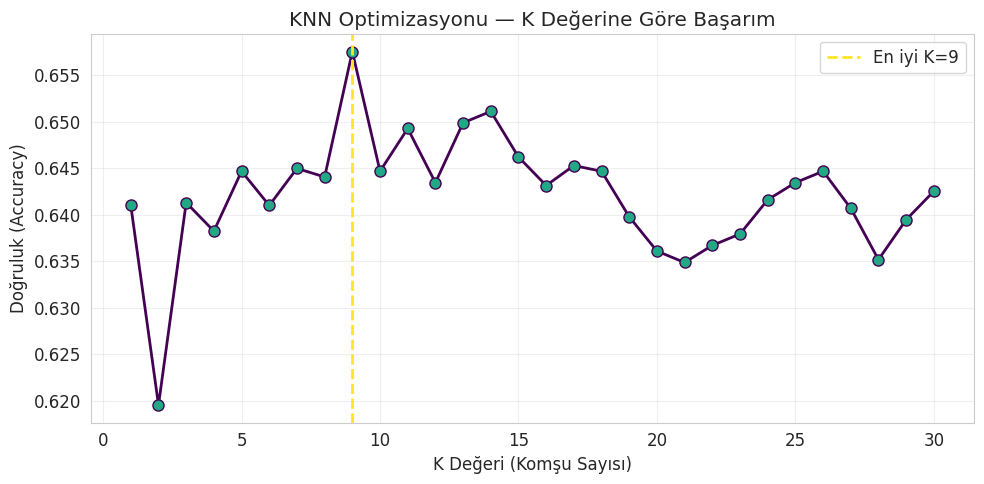

In [94]:
k_values = range(1, 31)
accuracies = []

# Hedef değişkeni sınıflandıralım (Binary Classification)
median_val = y_train.median()
y_train_class_loop = (y_train > median_val).astype(int)
y_test_class_loop = (y_test > median_val).astype(int)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_class_loop)
    acc = accuracy_score(y_test_class_loop, knn.predict(X_test_scaled))
    accuracies.append(acc)

best_k = k_values[accuracies.index(max(accuracies))]
print(f"En iyi K Değeri: {best_k}")
print(f"En iyi Accuracy: {max(accuracies):.4f}")

# Grafik çizimi ve renk güncellemeleri
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', color='#440154', linewidth=2, markersize=8, markerfacecolor='#22a884')
plt.axvline(x=best_k, color='#fde725', linestyle='--', label=f'En iyi K={best_k}', linewidth=2)
plt.xlabel('K Değeri (Komşu Sayısı)')
plt.ylabel('Doğruluk (Accuracy)')
plt.title('KNN Optimizasyonu — K Değerine Göre Başarım')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Metrik                          Log. Reg.       KNN (k=9)
Accuracy                           0.5809          0.6576
F1 - Düşük Satış                   0.5966          0.6441
F1 - Yüksek Satış                  0.5639          0.6700
Macro F1                           0.5802          0.6571


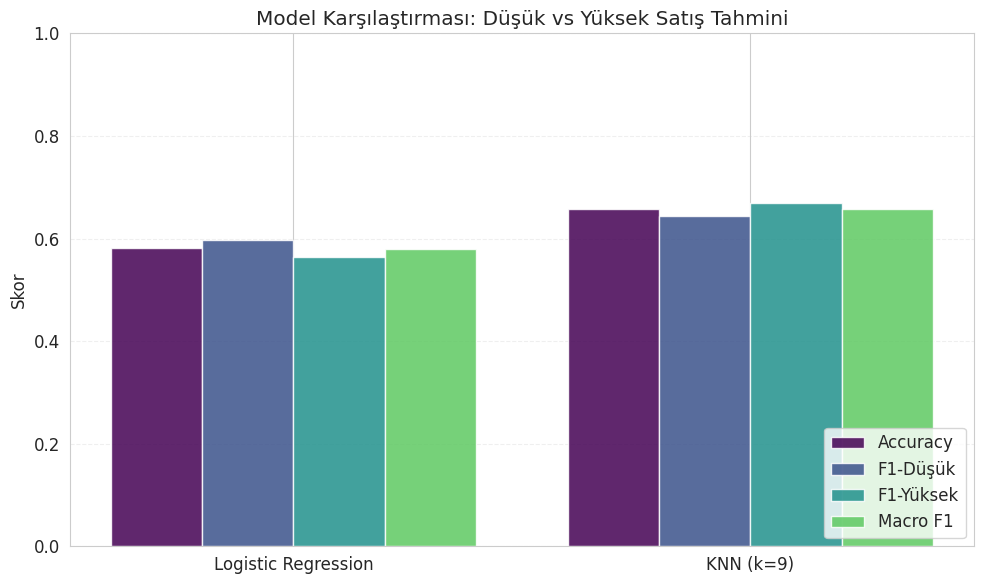

In [96]:
models = ['Logistic Regression', f'KNN (k={best_k})']

# Doğru hedef değişkenleri (class olanlar) kullanarak metrikleri hesaplayalım
accuracies_final = [
    accuracy_score(y_test_class, y_pred_lr),
    accuracy_score(y_test_class_ext, y_pred_knn_best)
]

# Sınıf bazlı F1 skorları (0: Düşük Satış, 1: Yüksek Satış)
f1_low_sales = [
    f1_score(y_test_class, y_pred_lr, pos_label=0),
    f1_score(y_test_class_ext, y_pred_knn_best, pos_label=0)
]
f1_high_sales = [
    f1_score(y_test_class, y_pred_lr, pos_label=1),
    f1_score(y_test_class_ext, y_pred_knn_best, pos_label=1)
]
macro_f1 = [
    f1_score(y_test_class, y_pred_lr, average='macro'),
    f1_score(y_test_class_ext, y_pred_knn_best, average='macro')
]

print("=" * 60)
print(f"{'Metrik':<25} {'Log. Reg.':>15} {'KNN (k=' + str(best_k) + ')':>15}")
print("=" * 60)
print(f"{'Accuracy':<25} {accuracies_final[0]:>15.4f} {accuracies_final[1]:>15.4f}")
print(f"{'F1 - Düşük Satış':<25} {f1_low_sales[0]:>15.4f} {f1_low_sales[1]:>15.4f}")
print(f"{'F1 - Yüksek Satış':<25} {f1_high_sales[0]:>15.4f} {f1_high_sales[1]:>15.4f}")
print(f"{'Macro F1':<25} {macro_f1[0]:>15.4f} {macro_f1[1]:>15.4f}")
print("=" * 60)

# Görselleştirme
x = np.arange(len(models))
width = 0.2
metrics = [accuracies_final, f1_low_sales, f1_high_sales, macro_f1]
labels  = ['Accuracy', 'F1-Düşük', 'F1-Yüksek', 'Macro F1']
colors  = ['#440154', '#3b528b', '#21918c', '#5ec962']

fig, ax = plt.subplots(figsize=(10, 6))
for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    ax.bar(x + i * width, metric, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Skor')
ax.set_title('Model Karşılaştırması: Düşük vs Yüksek Satış Tahmini')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()